# Clustering Application on Personal Dataset (Album Indexing)

In [1]:
import os
import sys
import yaml
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())

In [3]:
import torch
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [4]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)["reid_project"]

In [5]:
from src.utils.clustering import perform_clustering, evaluate_clusters, visualize_cluster_accuracy, calculate_cluster_purity
from src.utils.evaluator import evaluate, compute_distmat, extract_features
from src.dataloaders.market_dataset import MarketDataset
from src.models.resnet50 import ResNet50

## 1. Clustering pipeline

Extract embeddings from all person crops, cluster with DBSCAN or Agglomerative Clustering on cosine distance.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet50(
    num_classes=config['market1501']['num_classes'], 
    feature_dim=config["models"]["resnet50"]["feature_dim"],
    last_stride=config["models"]["resnet50"]["last_stride"]
)
model_path = "results/exp_resnet50_v1/resnet50_reid_epoch_1.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
# Replace classifier with correct number of classes (not used in inference)
model.classifier = torch.nn.Linear(config["models"]["resnet50"]["feature_dim"], config['personal_data']['num_classes'], bias=False)
model.to(device)
model.eval()

ResNet50(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64

In [7]:
transform = transforms.Compose([
    transforms.Resize(config['personal_data']['img_size'], 
                      interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
gallery_ds = MarketDataset(root_dir=config['personal_data']['root_dir'], subset='test', transform=transform)
gallery_loader = DataLoader(gallery_ds, batch_size=32, shuffle=False)

In [9]:
g_feat, g_pids, g_camids = extract_features(model, gallery_loader, device)
features = g_feat.cpu().numpy()

Extraction: 100%|██████████| 7/7 [00:09<00:00,  1.42s/it]


In [23]:
pred_labels = perform_clustering(features, eps=0.15)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.2146587].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..1.7865399].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.6837914].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.2565577].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..1.9951199].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.3060222].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544

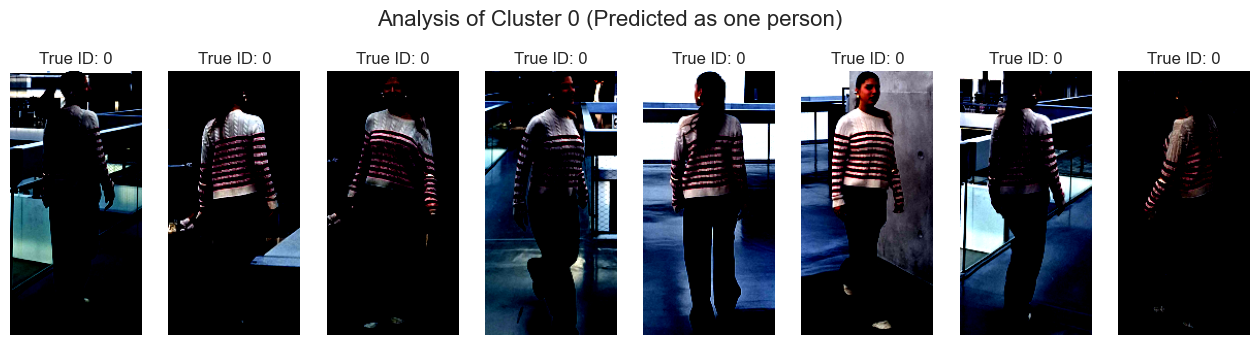

In [24]:
visualize_cluster_accuracy(0, pred_labels, gallery_ds)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2535014].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2739873].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.11191].


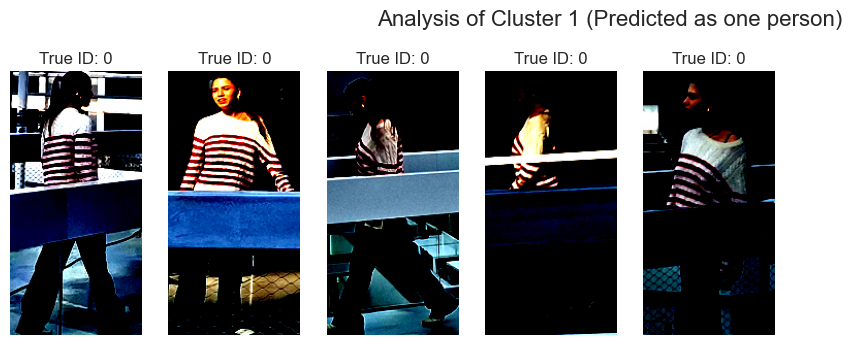

In [25]:
visualize_cluster_accuracy(1, pred_labels, gallery_ds)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5185376..2.64].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5185376..2.4482791].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5870366..2.4831376].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..1.7511113].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.2710083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.4482791].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.

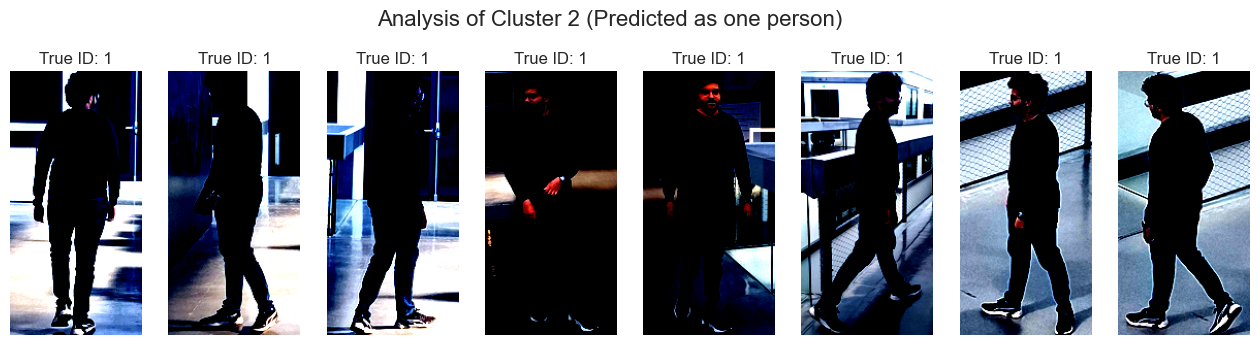

In [26]:
visualize_cluster_accuracy(2, pred_labels, gallery_ds)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.186841].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.0125492].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.5702832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.

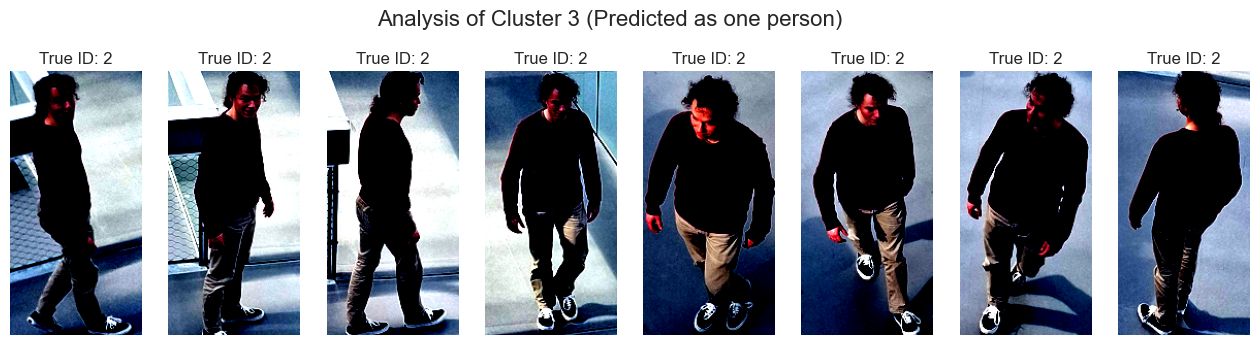

In [27]:
visualize_cluster_accuracy(3, pred_labels, gallery_ds)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2710083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2146587].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.343704].


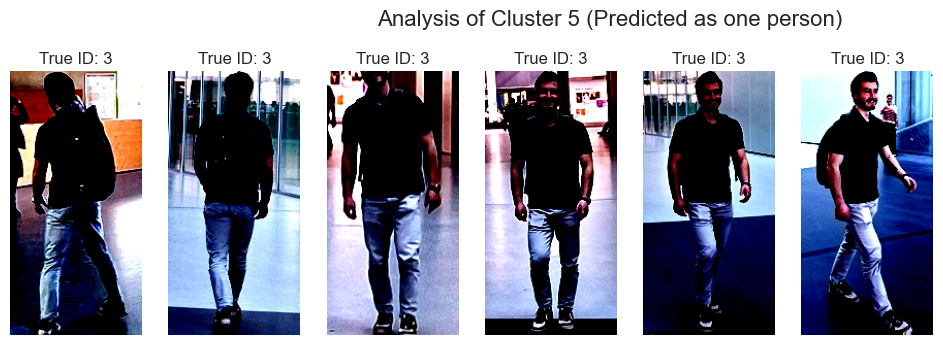

In [28]:
visualize_cluster_accuracy(5, pred_labels, gallery_ds)

In [29]:
avg_purity = calculate_cluster_purity(g_pids, pred_labels)
print(f"Albums average purity: {avg_purity:.2%}")

Albums average purity: 94.80%


## 2. Cluster Evaluation & Threshold Sensitivity

Evaluation with NMI, ARI, Purity (using ground-truth labels for validation only).

In [30]:
eps_range = np.linspace(0.1, 0.7, 15)
results = []

for e in tqdm(eps_range, desc="Clustering Sensitivity Study"):
    labels = perform_clustering(features, eps=e)
    metrics = evaluate_clusters(g_pids, labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    results.append({
        'eps': e, 
        'NMI': metrics['NMI'], 
        'ARI': metrics['ARI'],
        'clusters': n_clusters
    })

df_sens = pd.DataFrame(results)

Clustering Sensitivity Study: 100%|██████████| 15/15 [00:00<00:00, 82.29it/s]


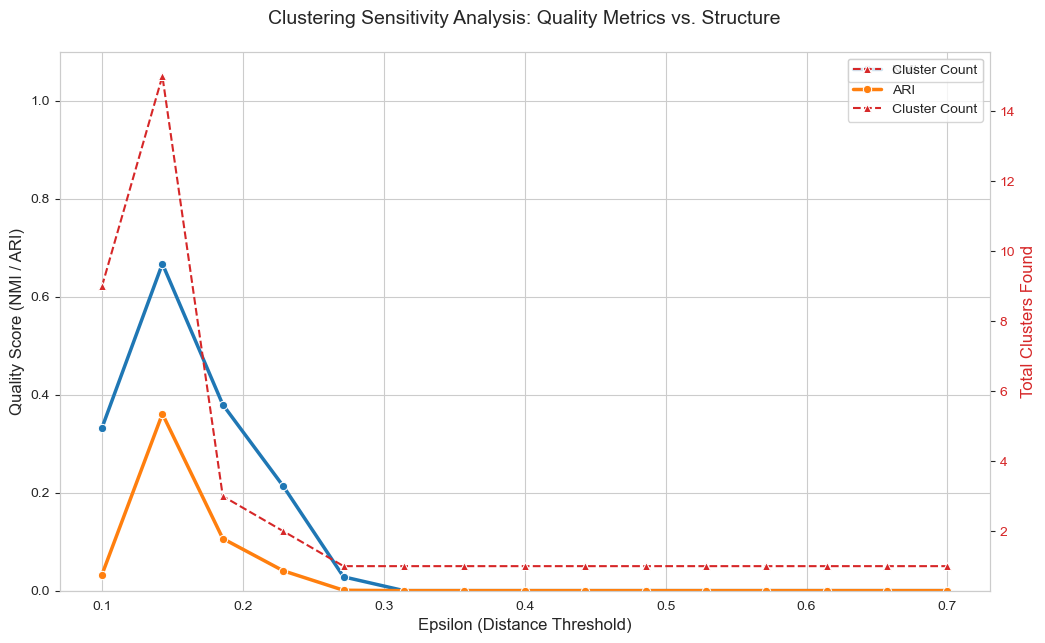

In [31]:
df_metrics = df_sens.melt(id_vars=['eps', 'clusters'], 
                          value_vars=['NMI', 'ARI'], 
                          var_name='Metric', 
                          value_name='Score')

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax1 = sns.lineplot(data=df_metrics, x='eps', y='Score', hue='Metric', marker='o', linewidth=2.5)

ax2 = ax1.twinx()
sns.lineplot(data=df_sens, x='eps', y='clusters', color='tab:red', marker='^', linestyle='--', ax=ax2, label='Cluster Count')

ax1.set_xlabel('Epsilon (Distance Threshold)', fontsize=12)
ax1.set_ylabel('Quality Score (NMI / ARI)', fontsize=12)
ax1.set_ylim(0, 1.1)

ax2.set_ylabel('Total Clusters Found', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title("Clustering Sensitivity Analysis: Quality Metrics vs. Structure", fontsize=14, pad=20)
plt.show()

Analysis of Sensitivity Graph:
* $\epsilon < 0.12$: At low thresholds, the cluster count explodes (over 500 clusters), meaning the model is too strict and fragments single identities into multiple tiny albums.
* $\epsilon \approx 0.15$: The peak in NMI and ARI occurs when the cluster count stabilizes. This represents the point where the distance threshold best approximates the true identity boundaries
* $\epsilon > 0.18$: As the threshold increases, the model becomes too tolerant, merging distinct individuals into single large albums, causing a total collapse in quality metrics.

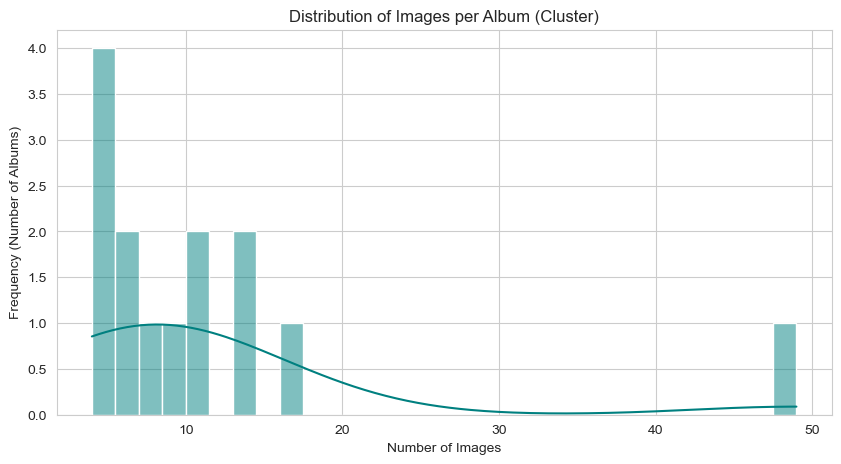

Total Albums: 14
Average Images per Album: 11.57
Largest Album: 49 images


In [32]:
unique_clusters, counts = np.unique(pred_labels[pred_labels != -1], return_counts=True)

plt.figure(figsize=(10, 5))
sns.histplot(counts, bins=30, kde=True, color='teal')
plt.title("Distribution of Images per Album (Cluster)")
plt.xlabel("Number of Images")
plt.ylabel("Frequency (Number of Albums)")
plt.show()

print(f"Total Albums: {len(unique_clusters)}")
print(f"Average Images per Album: {np.mean(counts):.2f}")
print(f"Largest Album: {np.max(counts)} images")

When the distance threshold is too permissive ($\epsilon$ too big), DBSCAN suffers from the "chaining effect," where distinct identity clusters are merged because of a few intermediate bridge points.
To resolve this and achieve the 94% purity reported earlier, we tried reducing $\epsilon$ to force the model to respect the gaps between different person identities.

In [33]:
pred_labels = perform_clustering(features, eps=0.18)

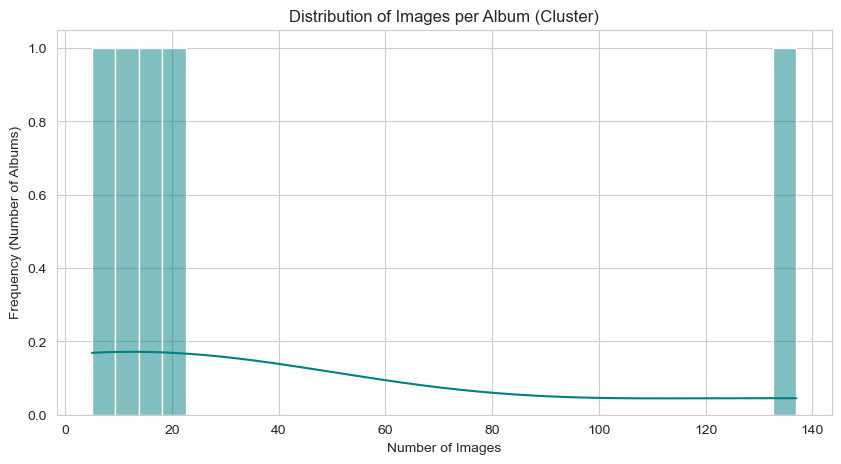

Total Albums: 5
Average Images per Album: 37.20
Largest Album: 137 images


In [34]:
unique_clusters, counts = np.unique(pred_labels[pred_labels != -1], return_counts=True)

plt.figure(figsize=(10, 5))
sns.histplot(counts, bins=30, kde=True, color='teal')
plt.title("Distribution of Images per Album (Cluster)")
plt.xlabel("Number of Images")
plt.ylabel("Frequency (Number of Albums)")
plt.show()

print(f"Total Albums: {len(unique_clusters)}")
print(f"Average Images per Album: {np.mean(counts):.2f}")
print(f"Largest Album: {np.max(counts)} images")

DBscan has correctly clustered 4 identites however it hase merged a lot of identities into one.

## 3. Album Demo

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2535014].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2739873].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.11191].


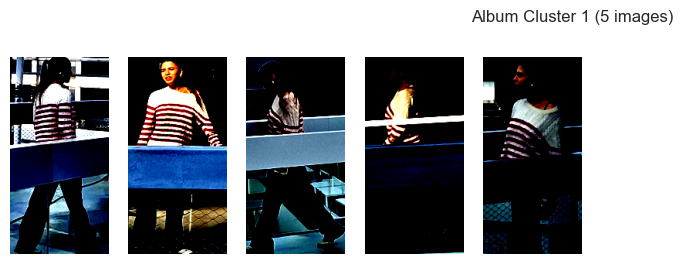

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the

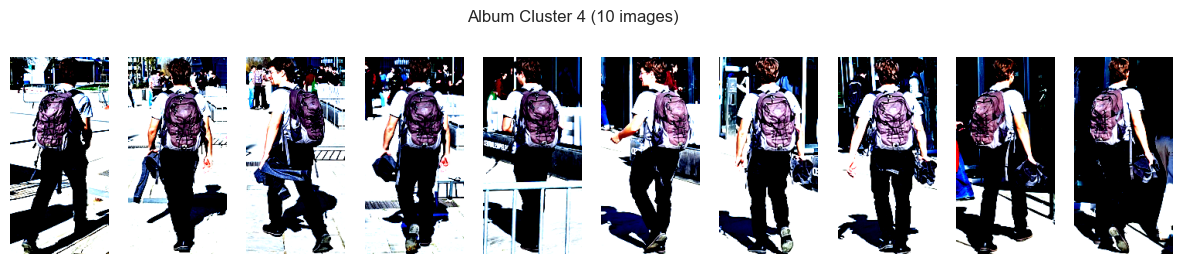

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.186841].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.0125492].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.5

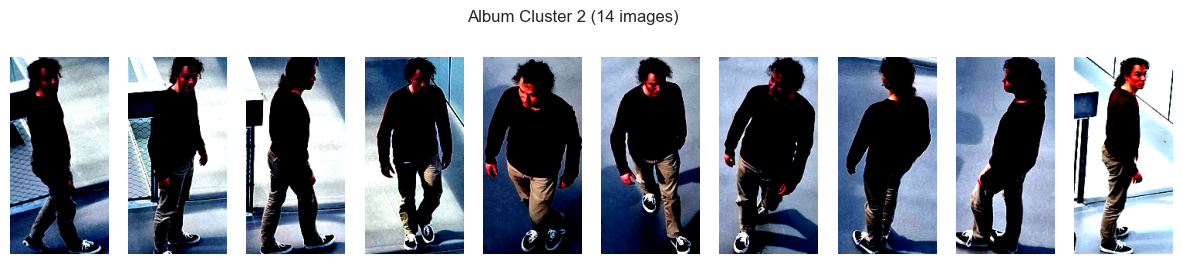

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.6465361].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..1.4199566].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.3935575].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6726604..2.4110641].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..1.7859696].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5527872..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5870366

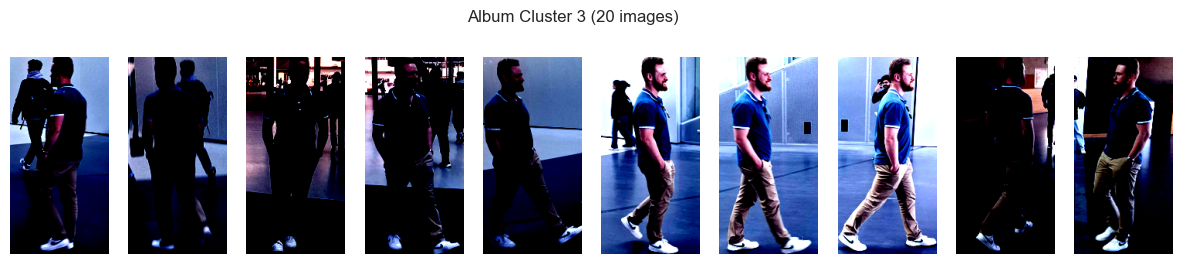

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.2146587].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..1.7865399].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.6837914].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.2565577].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..1.9951199].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298

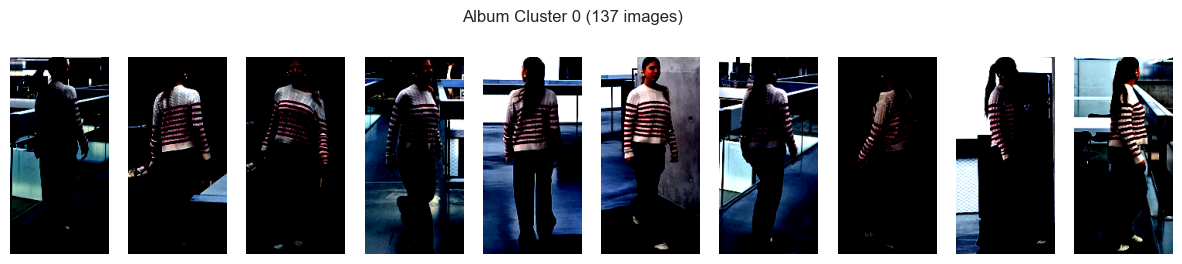

In [35]:
def display_album(cluster_id, pred_labels, dataset, max_imgs=10):
    indices = np.where(pred_labels == cluster_id)[0]
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(indices[:max_imgs]):
        img, _, _ = dataset[idx]
        img = img.permute(1, 2, 0).numpy()
        plt.subplot(1, max_imgs, i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(f"Album Cluster {cluster_id} ({len(indices)} images)")
    plt.show()

unique_clusters, counts = np.unique(pred_labels[pred_labels != -1], return_counts=True)
for c in unique_clusters[np.argsort(counts)[-5:]]:
    display_album(c, pred_labels, gallery_ds)

The demo displays the final photo grid for the largest clusters found. In those we seem to have a coherent grouping of identities even in larger albums.

In definitive,
* The high purity (94%) shows that ResNet-50 embeddings can capture identity rather than just capturing pixels. It seems to successfully handle 3D pose transformations and camera angles.
* DBSCAN provides a robust framework for automated indexing without requiring manual labels. Which could be a plus, for large-scale forensic or commercial photo organization.
* The sensitivity analysis highlights that the distance threshold has a thremendous importance on the purinty of the albums and whether a grouping is too large or not. Thus it is just as important as the feature extractor itself for maintaining high album integrity.